## Case Study: Trajectory Optimization

In this case study, we'll look at a simulation-based optimization example that uses either

1. A full-space method
2. A reduced-space method with an adjoint method
3. Automatic differentation

This example follows the trajectory optimization example shown in Section 6.2 of this paper:

Matthew Kelly, "An Introduction to Trajectory Optimization: How to Do Your Own Direct Collocation", SIAM Review, 2017, Vol 59, No 4, pp 849-904, https://epubs.siam.org/doi/pdf/10.1137/16M1062569

He also has an excellent YouTube video here: https://www.youtube.com/watch?v=wlkRYMVUZTs

The mass of the cart is $m_1$ and the pendulum consists of a pole of negligable mass of length $L$ connected to a mass of $m_2$. The position of the cart is given by $q_{1}$ and the angle the pendulum makes is $q_{2}$. The time derivative of the position and angle are $q_{3}$ and $q_{4}$, respectively. The system is controlled via a force $x$ applied to the cart.

The equations of motion of the cart-pole system are

\begin{equation*}
R_{0}(\dot{q}, q, x) = \begin{bmatrix}
q_3 - \dot{q}_1 \\
q_4 - \dot{q}_2 \\
((m_1 + m_2 (1 - \cos(q_2)^2)) \dot{q}_{3} - (L m_2 \sin(q_2) q_4^2 + x + m_2 g \cos(q_2) \sin(q_2))) \\
(L (m_1 + m_2 (1 - \cos(q_2)^2)) \dot{q}_4 + (L m_2 \cos(q_2) \sin(q_2) q_{4}^2 + x \cos(q_2) + (m_1 + m_2) g \sin(q_2) \\
\end{bmatrix} = 0
\end{equation*}

Here we've used a different notation for the governing equations, because this is not yet in the form we need. Here we have the issue of the time-dependence of the problem to handle. 

### Optimization problem formulation

The purpose of the trajectory optimization problem is to start the cart from a prescribed initial condition with the pendulum hanging below the cart, and end up at a final position with the pendulum inverted and the cart stationary. The goal is to reach this end configuration with as little control effort as possible.

The objective is therefore to minimize

\begin{equation*}
\min \int_{0}^{t_{f}} x(t)^2 dt 
\end{equation*}

Subject to the initial and final conditions

\begin{equation*}
q(0) = \begin{bmatrix}
0 \\
0 \\
0 \\
0 \\
\end{bmatrix} \qquad \qquad
q(t_f) = \begin{bmatrix}
d \\
\pi \\
0 \\
0 \\
\end{bmatrix}
\end{equation*}

Additionally, the states $q(t)$ must obey the governing equations such that $R(\dot{q}, q, x, t) = 0$.

### Discretization in time

To solve this problem, we need to discretize it in time. 
To do so, we'll divide up the time interval between $0$ and $t_f$ into $N$ time intervals.
The $N+1$ time levels that divide up the intervals will be

\begin{equation*}
t_{k} = \dfrac{k t_{f}}{N} \qquad \qquad k = 0, \ldots, N
\end{equation*}

Note that the time interval $\Delta t = t_{f}/N$ is constant and that $t_{0} = 0$ and $t_{N} = t_{f}$.
The state variable vector $u$ will consist of all the system variables at each point in time, excluding the initial conditions.
Here $q_{k} = q(t_{k}) \in \mathbb{R}^{4}$ for $k = 1, \ldots, N$ so that

\begin{equation*}
u = (q_1, q_2, q_3, \ldots, q_{N}) \in \mathbb{R}^{4N}
\end{equation*}

The design variable vector will consist of the force variable inputs at each point in time, where $x_{k} = x(t_{k})$ with the full design vector

\begin{equation*}
x = (x_0, x_1, x_2, \ldots, x_N) \in \mathbb{R}^{N+1}
\end{equation*}

To approximate the governing equations, we'll use the trapezoid rule. In this approach, we interpolate the system states $q(t)$ and control $x(t)$ linearly and impose the governing equations at the mid-point within time intervals.
This leads to the following approximations for the state varaibles

\begin{equation*}
q \approx \frac{1}{2} (q_{k} + q_{k-1})
\end{equation*}

and the following approximation for the velocity

\begin{equation*}
\dot{q} \approx \frac{1}{\Delta t} (q_{k} - q_{k-1})
\end{equation*}

In addition, the control at the mid-point is 

\begin{equation*}
x \approx \frac{1}{2} ( x_{k} + x_{k-1})
\end{equation*}

With these definitions, the following equation is enforced at the mid-point of each of the $N$ time-intervals

\begin{equation*}
R_{k}(q_{k}, q_{k-1}, x_k, x_{k-1}) = R_{0}\left(\dfrac{q_{k} - q_{k-1}}{\Delta t}, \dfrac{q_{k} + q_{k-1}}{2}, \dfrac{x_{k} + x_{k-1}}{2}\right) = 0
\end{equation*}

In the code outlined below, the system-level residual residuals are computed in the function `computeSystemResidual(self, qdot, q, x, res)` that takes $q$, $\dot{q}$ and the instantaneous control force at a given time.
These residuals are stored in a vector of length 4.
The function `computeTrajectory(self, x)` takes in the control force history from the $N+1$ time levels and solves the system equations to obtain the $q_{k}$ values for $k = 1, \ldots, N$.
At each step, it uses a Newton method to solve for the update until the system residuals satisfy a specified tolerance.

The full residual vector for the governing equations can be formed by concatenating the system residuals for each time level as

\begin{equation*}
R(u, x) = 
\begin{bmatrix}
R_{1}(q_1, q_0, x_{1}, x_{0}) \\
R_{2}(q_2, q_1, x_{2}, x_{1}) \\
R_{3}(q_3, q_2, x_{3}, x_{2}) \\
R_{4}(q_4, q_3, x_{4}, x_{3}) \\
\vdots \\
R_{N}(q_N, q_{N-1}, x_N, x_{N-1}) \\
\end{bmatrix} = 0
\end{equation*}

The full Jacobian matrix takes the form

\begin{equation*}
\dfrac{\partial R}{\partial u} = 
\begin{bmatrix}
\frac{\partial R_{1}}{\partial q_1} \\
\frac{\partial R_{2}}{\partial q_1} & \frac{\partial R_{2}}{\partial q_2} \\
& \frac{\partial R_{3}}{\partial q_2} & \frac{\partial R_{3}}{\partial q_3} \\
& & \frac{\partial R_{4}}{\partial q_3} & \frac{\partial R_{4}}{\partial q_4} \\ 
& & & \ddots & \ddots \\
& & & & \frac{\partial R_{N}}{\partial q_{N-1}} & \frac{\partial R_{N}}{\partial q_N} \\
\end{bmatrix}
\end{equation*}

The system Jacobian matrix computation is computed using the function `computeSystemJacobian(self, alpha, beta, qdot, q, x, J)`. This function computes a Jacobian matrix that combines the derivatives with respect to the state and time derivative of the state

\begin{equation*}
J(\alpha, \beta, \dot{q}, q) = \alpha \dfrac{\partial R_{0}}{\partial q} + \beta \dfrac{\partial R_{0}}{\partial \dot{q}}
\end{equation*}

Here $\alpha$ and $\beta$ are scalar coefficients.

For the trapezoid discretization, $\alpha = 1/2$ and $\beta = 1/\Delta t$ and the Jacobian matrices can be computed as

\begin{equation*}
\frac{\partial R_{k}}{\partial q_k} = J(\alpha, \beta, \dot{q}_k, q_k, x_{k})
\end{equation*}

\begin{equation*}
\frac{\partial R_{k}}{\partial q_{k-1}} = J(\alpha, -\beta, \dot{q}_k, q_k, x_{k})
\end{equation*}

### Adjoint method

In the trajectory optimization problem, the objective can be computed directly as a function of the design variables and does not require an adjoint.

The constraints are that at the final time, the state variables must satisfy the final conditions so that

\begin{equation*}
c(x, u) = q_{N} - q(t_{f}) = 0
\end{equation*}

In this case, there are 4 constraints that must be imposed, each one requiring its own adjoint implementation.
The adjoint equations are formed as

\begin{equation*}
\dfrac{\partial R}{\partial u}^{T} \psi = - \dfrac{\partial f}{\partial u}^{T}
\end{equation*}

For this problem, the transpose of the Jacobian matrix takes a special structure

\begin{equation*}
\dfrac{\partial R}{\partial u}^{T} = 
\begin{bmatrix}
\frac{\partial R_{1}}{\partial q_1}^{T} & \frac{\partial R_{2}}{\partial q_1}^{T} \\
& \frac{\partial R_{2}}{\partial q_2}^{T} & \frac{\partial R_{3}}{\partial q_2}^{T} \\
& & \frac{\partial R_{3}}{\partial q_3}^{T} & \frac{\partial R_{4}}{\partial q_3}^{T} \\
& & & \frac{\partial R_{4}}{\partial q_4}^{T} & \frac{\partial R_{5}}{\partial q_4}^{T} \\ 
& & & & \ddots & \ddots \\
& & & & & \frac{\partial R_{N}}{\partial q_{N}}^{T} \\
\end{bmatrix}
\end{equation*}

This leads to a system of equations at each time level that takes the form

\begin{equation*}
\frac{\partial R_{k}}{\partial q_k}^{T}\psi_{k} = - \dfrac{\partial f}{\partial q_{k}}^{T} - \frac{\partial R_{k+1}}{\partial q_k}^{T}\psi_{k+1}
\end{equation*}

At the final state when $k = N$, the equation is

\begin{equation*}
\frac{\partial R_{N}}{\partial q_N}^{T}\psi_{N} = - \dfrac{\partial f}{\partial q_{N}}^{T}
\end{equation*}

This full system of equations can be solved by starting from the final time at $k = N$, and marching backwards towards $k = 1$.

### Full-space method

In the full-space method, the design variables $x$ and the state variables $u$ are treated as co-equal variables that are controlled by the optimizer.
This means that the constraint Jacobian matrix must consist of both the Jacobian with respect to the design variables and state variables.

In the implementation below, these variables are concatenated together into the full space design variable vector

\begin{equation*}
x_{full} = (x_0, q_0, x_1, q_1, x_2, q_2, \ldots, x_{N}, q_{N})
\end{equation*}

The first set of constraints enforce the governing equations

\begin{equation*}
R(x_{full}) = 
\begin{bmatrix}
q_{0} \\
R_{1}(q_1, q_0, x_{1}, x_{0}) \\
R_{2}(q_2, q_1, x_{2}, x_{1}) \\
R_{3}(q_3, q_2, x_{3}, x_{2}) \\
R_{4}(q_4, q_3, x_{4}, x_{3}) \\
\vdots \\
R_{N}(q_N, q_{N-1}, x_N, x_{N-1}) \\
\end{bmatrix} = 0
\end{equation*}

The first equation enforces the initial condition while the remaining equations enforce the system equations at each collocation point with the trapezoid rule.
This residual is implemented in the class method `computeFullSpaceResidual(self, xfull)` below.

The constraint Jacobian matrix is therefore

\begin{equation*}
\dfrac{\partial R}{\partial x_{full}} =
\begin{bmatrix}
0 & I \\
\frac{\partial R_{1}}{\partial x_{0}} & \frac{\partial R_{1}}{\partial q_0} &
\frac{\partial R_{1}}{\partial x_{1}} & \frac{\partial R_{1}}{\partial q_1} \\
& & 
\frac{\partial R_{2}}{\partial x_{1}} & \frac{\partial R_{2}}{\partial q_1} &
\frac{\partial R_{2}}{\partial x_{2}} & \frac{\partial R_{2}}{\partial q_2} \\
& & & &
\frac{\partial R_{3}}{\partial x_{2}} & \frac{\partial R_{3}}{\partial q_2} &
\frac{\partial R_{3}}{\partial x_{3}} & \frac{\partial R_{3}}{\partial q_3} \\
& & & & & \ddots & \ddots & \ddots & \ddots  \\
& & & & & &
\frac{\partial R_{N}}{\partial x_{N-1}} & \frac{\partial R_{N}}{\partial q_{N-1}} &
\frac{\partial R_{N}}{\partial x_{N}} & \frac{\partial R_{N}}{\partial q_N} \\
\end{bmatrix}
\end{equation*}

This Jacobian is implemented using the class method `computeFullSpaceJacobian(self, xfull)`. It reuses the implementation of the system level Jacobian. Note that this Jacobian matrix has a well-structured sparsity pattern.

In addition to these constraints, the final conditions are enforced via a separate linear constraint that $q_{N} = q(t_{f})$.


Adjoint check
                  Adjoint              Complex step            Relative error
    7.126755849086700e-01     7.126755849086700e-01     0.000000000000000e+00
   -3.526521331318794e-02    -3.526521331318788e-02     1.770868208864940e-15
    6.491436146820301e-01     6.491436146820303e-01    -3.420577510167689e-16
    1.514499447997404e-01     1.514499447997405e-01    -7.330626802757731e-16
Full space check for the first 20 entries
      Full space Jacobian              Complex step            Relative error
    2.662984527988131e-01     2.662984527988131e-01     0.000000000000000e+00
    8.739151572551952e-01     8.739151572551952e-01     0.000000000000000e+00
    6.452005680618812e-01     6.452005680618812e-01     0.000000000000000e+00
    7.526375635366471e-01     7.526375635366471e-01     0.000000000000000e+00
   -1.176569787457975e+01    -1.176569787457975e+01    -3.019552020349152e-16
    5.811129140417664e+00     5.811129140417665e+00    -1.528409364580545e-16
   -1.24

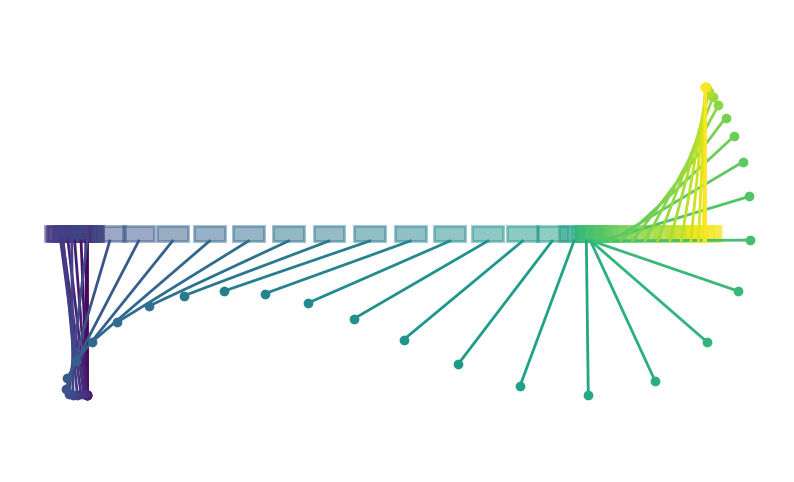

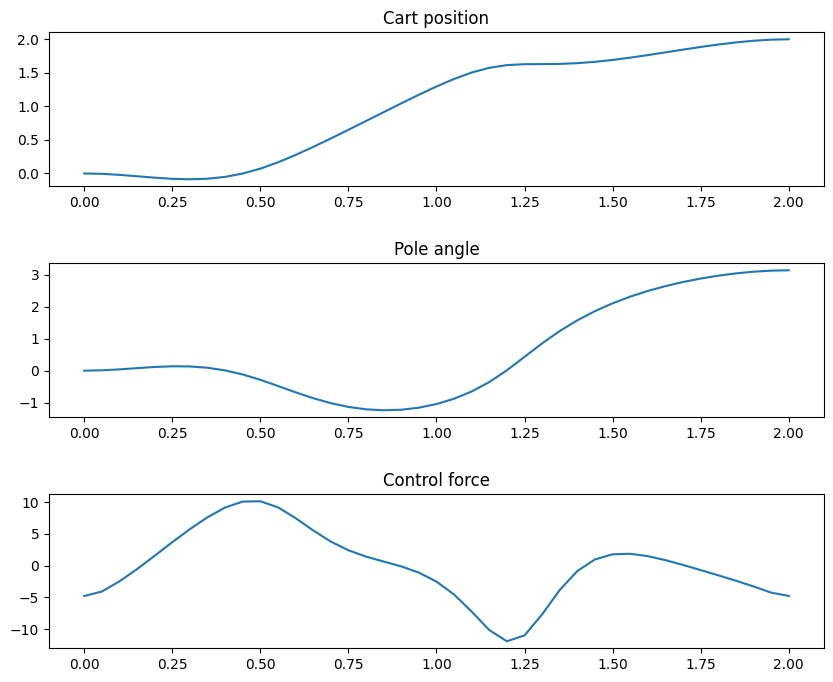

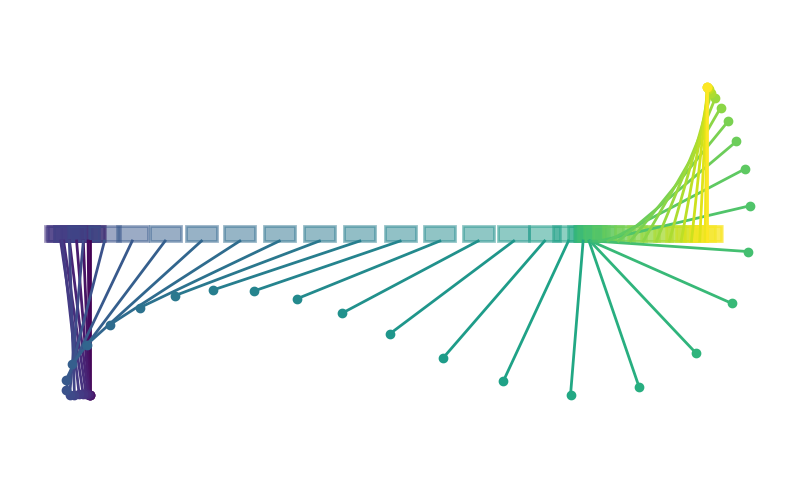

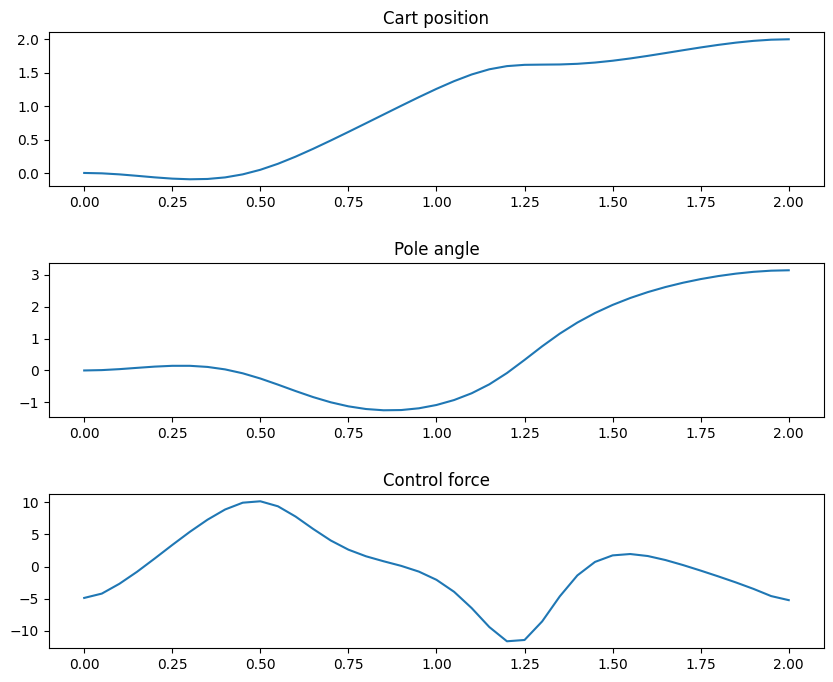

In [18]:
import numpy as np
from scipy.optimize import minimize
from scipy.optimize import LinearConstraint, NonlinearConstraint
import matplotlib.pylab as plt

class CartPole:
    def __init__(self, t, m1=1.0, m2=0.3, L=0.5):
        """
        Initialize the cart-pole class
        """
        self.m1 = m1
        self.m2 = m2
        self.L = L
        self.g = 9.81
        self.t = t

        # The number of iterations
        self.iter_counter = 0

        # Compute the Delta t values
        dt = self.t[1:] - self.t[:-1]

        # Compute the weights for evaluating the integral in the
        # objective function
        self.h = np.zeros(t.shape[0])
        self.h[:-1] += 0.5 * dt
        self.h[1:] += 0.5 * dt
        
        self.max_newton_iters = 10
        self.newton_tol = 1e-10
        self.fobj_scale = 10.0
        self.con_scale = 1.0

        return

    def evalObj(self, x):
        """Evaluate the objective"""

        # Compute the sum square of the weights
        fobj = self.fobj_scale*np.sum(self.h*x[:]**2)

        return fobj
    
    def evalObjGradient(self, x):
        """Evaluate the objective gradient"""
        
        g = 2.0*self.fobj_scale*self.h*x[:]
        
        return g

    def evalCon(self, x):
        """Evaluate the constraints"""
        con = np.zeros(4, dtype=x.dtype)

        # Compute the full trajectory based on the input forces
        self.q = self.computeTrajectory(x[:])

        # Compute the constraints
        con[0] = self.q[-1, 0] - 2.0
        con[1] = self.q[-1, 1] - np.pi
        con[2] = self.q[-1, 2]
        con[3] = self.q[-1, 3]
        con[:] *= self.con_scale

        return con

    def evalConGradient(self, x):
        """Evaluate the constraint gradient"""
        
        q = self.computeTrajectory(x[:])

        # Create a vector to store the derivative of the constraints
        dcdx = np.zeros((4, self.t.shape[0]), dtype=x.dtype)
        for state in range(4):
            self.computeAdjointDeriv(q, x[:], state, dcdx[state, :])        
        dcdx *= self.con_scale

        return dcdx

    def computeSystemResidual(self, qdot, q, x, res):
        """
        Compute the residual of the system dynamics.
        
        res = R0(qdot, q, x)
        """
        # q = [q1, q2, q1dot, q2dot]
        res[0] = q[2] - qdot[0]
        res[1] = q[3] - qdot[1]

        # Compute the residual for the first equation of motion
        res[2] = ((self.m1 + self.m2*(1.0 - np.cos(q[1])**2))*qdot[2] -
            (self.L*self.m2*np.sin(q[1])*q[3]**2 + x +
            self.m2*self.g*np.cos(q[1])*np.sin(q[1])))

        # Compute the residual for the second equation of motion
        res[3] = (self.L*(self.m1 + self.m2*(1.0 - np.cos(q[1])**2))*qdot[3] +
            (self.L*self.m2*np.cos(q[1])*np.sin(q[1])*q[3]**2 +
            x*np.cos(q[1]) +
            (self.m1 + self.m2)*self.g*np.sin(q[1])))

        return

    def computeSystemJacobian(self, alpha, beta, qdot, q, x, J):
        """
        Compute the Jacobian of the system dynamics.
        
        J = alpha * dR0/dq + beta * dR0/dqdot
        """

        J[:,:] = 0.0
        J[0,0] = -beta
        J[0,2] = alpha
        J[1,1] = -beta
        J[1,3] = alpha
        J[2,1] = alpha*(self.m2*(-q[3]**2*self.L*np.cos(q[1]) +
                                 qdot[2]*np.sin(2*q[1]) - self.g*np.cos(2*q[1])))
        J[2,2] = beta*(1.0*self.m1 + 1.0*self.m2*np.sin(q[1])**2)
        J[2,3] = -2*alpha*q[3]*self.L*self.m2*np.sin(q[1])
        J[3,1] = alpha*((q[3]**2*self.L*self.m2*np.cos(2*q[1]) +
                         qdot[3]*self.L*self.m2*np.sin(2*q[1]) +
                         self.g*self.m1*np.cos(q[1]) +
                         self.g*self.m2*np.cos(q[1]) - x*np.sin(q[1])))
        J[3,3] = (alpha*(q[3]*self.L*self.m2*np.sin(2*q[1])) +
                  beta*self.L*(self.m1 + self.m2*np.sin(q[1])**2))

        return

    def computeSystemControlJacobian(self, qdot, q, x, Jx):
        """
        Compute the residual of the system dynamics.
        """
        Jx[0] = 0.0
        Jx[1] = 0.0
        Jx[2] = -1.0
        Jx[3] = np.cos(q[1])
        
        return
    
    def verifyJacobian(self, h=1e-30):
        """
        Use complex-step to verify the Jacobian matrix
        """
        q = np.random.uniform(size=4)
        qdot = np.random.uniform(size=4)
        p = np.random.uniform(size=4)
        u = -1.72

        alpha = 0.154
        beta = 0.721
        J = np.zeros((4, 4))
        self.computeSystemJacobian(alpha, beta, qdot, q, u, J)
        Jp = np.dot(J, p)

        res = np.zeros(4, dtype=complex)
        self.computeSystemResidual(qdot + h*beta*1j*p, q + h*alpha*1j*p, u, res)
        Jpc = res.imag/h

        print('Relative error: ', (Jp - Jpc)/Jpc)
        return

    def computeTrajectory(self, x):
        """
        Given the input control force x[i] for t[i] = 0, to t final,
        compute the trajectory.
        """

        # Allocate space for the state variables
        q = np.zeros((len(self.t), 4), dtype=x.dtype)

        # Set the initial conditions.
        q[0, :] = 0.0

        # Compute the residual and Jacobian
        res = np.zeros(4, dtype=q.dtype)
        J = np.zeros((4, 4), dtype=q.dtype)

        # Integrate forward in time
        for k in range(1, len(self.t)):
            # Copy the starting point for the first iteration
            q[k, :] = q[k-1, :]

            # Solve the nonlinear equations for q[k]
            for j in range(self.max_newton_iters):
                # Compute the state values at the mid-point
                alpha = 0.5
                qk = alpha*(q[k, :] + q[k-1, :])

                # Compute the time derivative approximation
                beta = 1.0/(self.t[k] - self.t[k-1])
                qkdot = beta*(q[k, :] - q[k-1, :])
                
                # Compute the control value at the mid-point
                xk = 0.5*(x[k] + x[k-1])
                            
                # Compute the residuals
                self.computeSystemResidual(qkdot, qk, xk, res)
                
                # Compute the system Jacobian matrix
                self.computeSystemJacobian(alpha, beta, qkdot, qk, xk, J)
                
                # Solve for the update using Newton's method
                update = np.linalg.solve(J, res)
                q[k, :] -= update

                # Check for convergence
                rnorm = np.sqrt(np.dot(res, res))
                if rnorm < self.newton_tol:
                    break

        return q

    def computeAdjointDeriv(self, q, x, state, dfdx):
        """
        Compute the derivative of the final state with the specified state
        index with respect to the control.
        """
        # Zero-out the contributions to the state variables
        dfdx[:] = 0.0

        # Set the right-hand-side for the adjoint equations
        res = np.zeros(4, dtype=dfdx.dtype)
        res[state] = 1.0 # df/du
        
        # The Jacobian matrix
        J = np.zeros((4, 4), dtype=dfdx.dtype)
        
        # The Jacobian matrix w.r.t. the control
        Jx = np.zeros(4, dtype=dfdx.dtype)

        # Integrate the adjoint in reverse
        for k in range(len(self.t)-1, 0, -1):
            # Compute the state values at the mid-point
            alpha = 0.5
            qk = alpha*(q[k, :] + q[k-1, :])

            # Compute the time derivative approximation
            beta = 1.0/(self.t[k] - self.t[k-1])
            qkdot = beta*(q[k, :] - q[k-1, :])

            # Compute the control value at the mid-point
            xk = 0.5*(x[k] + x[k-1])

            # Compute the Jacobian matrix
            self.computeSystemJacobian(alpha, beta, qkdot, qk, xk, J)

            # Compute the adjoint variables
            adjoint = -np.linalg.solve(J.T, res)

            # Compute the control input Jacobian
            self.computeSystemControlJacobian(qkdot, qk, xk, Jx)
            
            # Add the contribution from the total derivative            
            dfdx[k] += 0.5*np.dot(Jx, adjoint)            
            dfdx[k-1] += 0.5*np.dot(Jx, adjoint)

            # Compute the right-hand-side for the next adjoint
            self.computeSystemJacobian(alpha, -beta, qkdot, qk, xk, J)
            
            # Update the right-hand-side for the adjoint
            res = np.dot(J.T, adjoint)

        return
    
    def evalFullSpaceObj(self, xfull):
        """Evaluate the objective using the full space"""

        # Compute the sum square of the weights
        fobj = self.fobj_scale*np.sum(self.h*xfull[::5]**2)

        return fobj
    
    def evalFullSpaceObjGradient(self, xfull):
        """Evaluate the objective gradient"""
        
        g = np.zeros(xfull.shape)
        g[::5] = 2.0*self.fobj_scale*self.h*xfull[::5]
        
        return g
    
    def computeFullSpaceResidual(self, xfull):
        """
        Compute the full space residuals - concatenation of the residuals
        from all the time steps
        """
        
        # Reshape the full vector of full space variables
        xfull = xfull.reshape(-1, 5)
        
        x = xfull[:, 0]
        q = xfull[:, 1::]
        
        # Allocate the residuals
        res = np.zeros(4*self.t.shape[0], dtype=xfull.dtype)
        
        # Set the initial conditions
        res[:4] = q[0, :]
        
        # Set the residual values at each point in time
        for k in range(1, len(self.t)):
            # Compute the state values at the mid-point
            alpha = 0.5
            qk = alpha*(q[k, :] + q[k-1, :])

            # Compute the time derivative approximation
            beta = 1.0/(t[k] - t[k-1])
            qkdot = beta*(q[k, :] - q[k-1, :])

            # Compute the control value at the mid-point
            xk = 0.5*(x[k] + x[k-1])

            # Compute the residuals
            self.computeSystemResidual(qkdot, qk, xk, res[4*k:4*(k+1)])
                
        return res
    
    def computeFullSpaceJacobian(self, xfull):
        """
        The Jacobian matrix
        """
        
        # Reshape the full vector of full space variables
        xfull = xfull.reshape(-1, 5)
        
        x = xfull[:, 0]
        q = xfull[:, 1::]
        
        # Allocate the full Jacobian matrix
        J = np.zeros((4*self.t.shape[0], 5*self.t.shape[0]), dtype=xfull.dtype)
        
        # The Jacobian matrix
        J0 = np.zeros((4, 4), dtype=xfull.dtype)
        
        # The Jacobian matrix w.r.t. the control
        Jx = np.zeros(4, dtype=xfull.dtype)

        # Set the identity matrix
        for i in range(4):
            J[i, i+1] = 1.0
    
        for k in range(1, len(self.t)):
            # Compute the state values at the mid-point
            alpha = 0.5
            qk = alpha*(q[k, :] + q[k-1, :])

            # Compute the time derivative approximation
            beta = 1.0/(self.t[k] - self.t[k-1])
            qkdot = beta*(q[k, :] - q[k-1, :])

            # Compute the control value at the mid-point
            xk = 0.5*(x[k] + x[k-1])

            # Compute the control input Jacobian
            self.computeSystemControlJacobian(qkdot, qk, xk, Jx)

            # Compute the Jacobian matrix
            self.computeSystemJacobian(alpha, beta, qkdot, qk, xk, J0)

            J[4*k:4*(k+1), 5*k] = 0.5*Jx
            for i in range(4):
                J[4*k:4*(k+1), 5*k+i+1] = J0[:, i]       
            
            # Compute the derivative w.r.t. the previous state
            self.computeSystemJacobian(alpha, -beta, qkdot, qk, xk, J0)
            
            J[4*k:4*(k+1), 5*(k-1)] = 0.5*Jx            
            for i in range(4):
                J[4*k:4*(k+1), 5*(k-1)+i+1] = J0[:, i]
        
        return J

    def visualize(self, xu, q=None, skip=5):
        """
        Visualize the output from a simulation
        """

        import matplotlib.pylab as plt
        from matplotlib.collections import LineCollection
        import matplotlib.cm as cm

        # Set the values of the states
        if q is None:
            q = self.computeTrajectory(xu)

        # Create the time-lapse visualization
        fig = plt.figure(figsize=(10, 6))
        plt.axis('equal')
        plt.axis('off')

        values = np.linspace(0, 1.0, q.shape[0])
        cmap = cm.get_cmap('viridis')

        hx = 0.05
        hy = 0.05
        xpts = []
        ypts = []
        for i in range(q.shape[0]):
            color = cmap(values[i])

            x1 = q[i,0]
            y1 = 0.0
            x2 = q[i,0] + self.L*np.sin(q[i,1])
            y2 = -self.L*np.cos(q[i,1])

            xpts.append(x2)
            ypts.append(y2)

            plt.plot([x1, x2], [y1, y2], linewidth=2, color=color)
            plt.fill([x1 - hx, x1 + hx, x1 + hx, x1 - hx, x1 - hx],
                     [y1, y1, y1 + hy, y1 + hy, y1], alpha=0.5, linewidth=2, color=color)
            plt.plot([x2], [y2], color=color, marker='o')

        fig, ax = plt.subplots(3, 1, figsize=(10, 8))
        plt.subplots_adjust(hspace=0.5)
        
        ax[0].plot(self.t, q[:,0])
        ax[0].set_title('Cart position')
        ax[1].plot(self.t, q[:,1])
        ax[1].set_title('Pole angle')
        ax[2].plot(self.t, xu)
        ax[2].set_title('Control force')

        plt.show()

# Create the cart pole object
N = 40
t = np.linspace(0, 2.0, N+1)
trajectory = CartPole(t)

# Perform a complex-step verification for the adjoint 
h = 1e-30
x0 = np.random.uniform(size=N+1)
p = np.random.uniform(size=N+1)

adjoint_result = np.dot(trajectory.evalConGradient(x0), p)
cs_result = trajectory.evalCon(x0 + h *1j*p).imag/h

print('Adjoint check')
print('{0:>25s} {1:>25s} {2:>25s}'.format('Adjoint', 'Complex step', 'Relative error'))
for adjoint, cs in zip(adjoint_result, cs_result):
    print('{0:25.15e} {1:25.15e} {2:25.15e}'.format(adjoint, cs, (adjoint - cs)/cs))

x0 = np.random.uniform(size=5*(N+1))
p = np.random.uniform(size=5*(N+1))
adjoint_result = np.dot(trajectory.computeFullSpaceJacobian(x0), p)
cs_result = trajectory.computeFullSpaceResidual(x0 + h *1j*p).imag/h

print('Full space check for the first 20 entries')
print('{0:>25s} {1:>25s} {2:>25s}'.format('Full space Jacobian', 'Complex step', 'Relative error'))
for adjoint, cs in zip(adjoint_result[:20], cs_result[:20]):
    print('{0:25.15e} {1:25.15e} {2:25.15e}'.format(adjoint, cs, (adjoint - cs)/cs))

# Solve the problem using the reduced-space method with the adjoint implementation
# Set up the nonlinear constraint for the final state variables.
lb = np.zeros(4)
ub = np.zeros(4)
con = NonlinearConstraint(trajectory.evalCon, lb, ub,
                          jac=trajectory.evalConGradient)

# Solve the trajectory optimization problem using the adjoint
x = np.ones(N+1)
res = minimize(trajectory.evalObj, x, method='trust-constr',
               jac=trajectory.evalObjGradient,
               constraints=con, options={'maxiter': 250})

trajectory.visualize(res.x, skip=3)

# Solve the problem using the full-space method.
# Set up the full space governing equation constraints 
lb = np.zeros(4*(N+1))
ub = np.zeros(4*(N+1))
fullcon = NonlinearConstraint(trajectory.computeFullSpaceResidual, lb, ub,
                              jac=trajectory.computeFullSpaceJacobian)

# Set up the linear constraint for the final conditions
A = np.zeros((4, 5*(N+1)))
for i in range(4):
    A[i, 5*N + i+1] = 1.0

lb = np.zeros(4)
lb[0] = 2.0
lb[1] = np.pi
finalcon = LinearConstraint(A, lb, lb)

# Solve the trajectory optimization problem using the adjoint
x = np.ones(5*(N+1))
res = minimize(trajectory.evalFullSpaceObj, x, method='trust-constr',
               jac=trajectory.evalFullSpaceObjGradient,
               constraints=(fullcon, finalcon), options={'maxiter': 250})

q = res.x.reshape(-1, 5)[:, 1::]
trajectory.visualize(res.x[::5], q=q, skip=3)


### Automatic differentation

In this example, we compute the gradient of the constraint functions directly using automatic differentation.
This example uses the `autograd` AD tool that has some limitations in the types of operations it can handle.
As a result, the code in `computeSystemResidual` and `computeSystemJacobian` now create native python lists and lists of lists that are then used to create `numpy` arrays.
These arrays are then returned from those functions. 
This modification enables `autograd` to differentiate these methods directly.
In addition, `computeTrajectory` is modified to store the state variables `q` as a list of `numpy` arrays.
These code modifications do not change the algorithm, but can be awkward or require some restructuring of the code.
Nonetheless, AD is a powerful tool for directly computing the gradient of functions of interest, even for complex analysis problems.

To test the derivative computed using AD, we use the complex step method. We pick a random design variable vector, $x_{0}$, and a random direction $p$ and compare the complex-step directional derivative to the gradient computed using `autodiff`.

\begin{equation*}
\dfrac{\text{imag}\{ f(x_{0} + i h p)\}}{h} \approx \nabla f(x_{0})^{T} p
\end{equation*}

Here $h = 1e-30$ is a small complex-step perturbation.

Within the code, the derivative code is generated using the `grad` function. The resulting directional derivative is stored in `ad` while the complex-step approximation is stored in `cs`. These values are computed using the following code

```python
gradFunc = grad(lambda x : trajectory.evalCon(x, state=state))
ad = np.dot(gradFunc(x0), p)
cs = trajectory.evalCon(x0 + h *1j*p, state=state).imag/h
```

In [19]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt

class CartPole:
    def __init__(self, t, m1=1.0, m2=0.3, L=0.5):
        """
        Initialize the cart-pole class
        """
        self.m1 = m1
        self.m2 = m2
        self.L = L
        self.g = 9.81
        self.t = t

        # The number of iterations
        self.iter_counter = 0

        # Compute the Delta t values
        dt = self.t[1:] - self.t[:-1]

        # Compute the weights for evaluating the integral in the
        # objective function
        self.h = np.zeros(t.shape[0])
        self.h[:-1] += 0.5 * dt
        self.h[1:] += 0.5 * dt
        
        self.max_newton_iters = 10
        self.newton_tol = 1e-10
        self.fobj_scale = 10.0
        self.con_scale = 1.0

        return

    def evalObj(self, x):
        """Evaluate the objective"""

        # Compute the sum square of the weights
        fobj = self.fobj_scale*np.sum(self.h*x[:]**2)

        return fobj

    def evalCon(self, x, state=0):
        """Evaluate the constraint for the AD tool"""
        q = self.computeTrajectory(x)
        return q[-1][state]
    
    def computeSystemResidual(self, qdot, q, x):
        """
        Compute the residual of the system dynamics.
        
        res = R0(qdot, q, x)
        """
        
        R0 = [
            q[2] - qdot[0],
            q[3] - qdot[1],
            ((self.m1 + self.m2*(1.0 - np.cos(q[1])**2))*qdot[2] -
                (self.L*self.m2*np.sin(q[1])*q[3]**2 + x +
                self.m2*self.g*np.cos(q[1])*np.sin(q[1]))),
            (self.L*(self.m1 + self.m2*(1.0 - np.cos(q[1])**2))*qdot[3] +
                (self.L*self.m2*np.cos(q[1])*np.sin(q[1])*q[3]**2 +
                x*np.cos(q[1]) +
                (self.m1 + self.m2)*self.g*np.sin(q[1])))]

        return np.array(R0)

    def computeSystemJacobian(self, alpha, beta, qdot, q, x):
        """
        Compute the Jacobian of the system dynamics.
        
        J = alpha * dR0/dq + beta * dR0/dqdot
        """

        J0 = [
            [-beta, 0, alpha, 0 ],
            [0, -beta, 0, alpha],
            [0, alpha*(self.m2*(-q[3]**2*self.L*np.cos(q[1]) +
                                 qdot[2]*np.sin(2*q[1]) - self.g*np.cos(2*q[1]))),
             beta*(1.0*self.m1 + 1.0*self.m2*np.sin(q[1])**2),
             -2*alpha*q[3]*self.L*self.m2*np.sin(q[1])],
            [0, alpha*((q[3]**2*self.L*self.m2*np.cos(2*q[1]) +
                         qdot[3]*self.L*self.m2*np.sin(2*q[1]) +
                         self.g*self.m1*np.cos(q[1]) +
                         self.g*self.m2*np.cos(q[1]) - x*np.sin(q[1]))), 0,
             (alpha*(q[3]*self.L*self.m2*np.sin(2*q[1])) +
                  beta*self.L*(self.m1 + self.m2*np.sin(q[1])**2))]]

        return np.array(J0)
    
    def computeTrajectory(self, x):
        """
        Given the input control force x[i] for t[i] = 0, to t final,
        compute the trajectory.
        """

        # Set the state variables
        q = [np.zeros(4)]

        # Integrate forward in time
        for k in range(1, len(self.t)):
            # Copy the starting point for the first iteration
            q.append(np.array(q[-1]))
                
            # Solve the nonlinear equations for q[k]
            for j in range(self.max_newton_iters):
                # Compute the state values at the mid-point
                alpha = 0.5
                qk = alpha*(q[k] + q[k-1])

                # Compute the time derivative approximation
                beta = 1.0/(self.t[k] - self.t[k-1])
                qkdot = beta*(q[k] - q[k-1])
                
                # Compute the control value at the mid-point
                xk = 0.5*(x[k] + x[k-1])
                            
                # Compute the residuals
                res = self.computeSystemResidual(qkdot, qk, xk)
                
                # Compute the system Jacobian matrix
                J = self.computeSystemJacobian(alpha, beta, qkdot, qk, xk)
                
                # Solve for the update using Newton's method
                q[k] = q[k] - np.linalg.solve(J, res)

                # Check for convergence
                rnorm = np.sqrt(np.dot(res, res))
                if rnorm < self.newton_tol:
                    break

        return q
        
# Create the cart pole object
N = 40
t = np.linspace(0, 2.0, N+1)
trajectory = CartPole(t)

# Perform a complex-step verification for the adjoint 
h = 1e-30
x0 = np.random.uniform(size=N+1)
p = np.random.uniform(size=N+1)

print('Adjoint check')
print('{0:>25s} {1:>25s} {2:>25s}'.format('Adjoint', 'Complex step', 'Relative error'))

for state in range(4):
    # Create the gradient function
    gradFunc = grad(lambda x : trajectory.evalCon(x, state=state))
    ad = np.dot(gradFunc(x0), p)
    cs = trajectory.evalCon(x0 + h *1j*p, state=state).imag/h

    print('{0:25.15e} {1:25.15e} {2:25.15e}'.format(ad, cs, (ad - cs)/cs))

Adjoint check
                  Adjoint              Complex step            Relative error
    7.395982146044529e-01     7.395982146044530e-01    -1.501116420648634e-16
   -5.751724277753367e-02    -5.751724277753367e-02    -0.000000000000000e+00
    7.085705987205919e-01     7.085705987205916e-01     4.700546536773313e-16
    2.572440825236649e-01     2.572440825236648e-01     4.315835037810922e-16


### Minimum Time to Climb Problem

The goal of this problem is to find the angle-of-attack $\alpha(t)$, as a function of time for an aircraft.
The objective is to minimize the amount of time taken for the aircraft to accelerate and reach a final altitude and velocity at $t = t_{f}$, starting from a lower altitude and slower velocity at $t = 0$.

The aircraft is governed by the following dynamics

\begin{align*}
\frac{dv}{dt} &= \frac{T}{m} \cos \alpha - \frac{D}{m} - g \sin \gamma \\
\frac{d\gamma}{dt} &= \frac{T}{m v} \sin \alpha + \frac{L}{m v} - \frac{g \cos \gamma}{v} \\
\frac{dh}{dt} &= v \sin \gamma \\
\frac{dr}{dt} &= v \cos \gamma \\
\frac{dm}{dt} &= - \frac{T}{g I_{sp}}
\end{align*}

Here $v$ is the velocity of the aircraft, $h$ is the altitude, $r$ is the distance flown, $\gamma$ is the flight-path angle in degrees and $m$ is the mass.
The thrust is given by $T$, $D$ is the drag, $L$ is the lift.
In this example the $\alpha$ and $\gamma$ values are given in degrees.

The free-body-diagram for the aircraft is shown below.

![Aircraft free-body diagram](min_time_climb_fbd.png)

These dynamics describe the trajectory of any aircraft. Our specific aircraft below is modeled on a supersonic interceptor. The goal is to accelerate the interceptor from near ground level to an altitude of 20 km and Mach 1.

The initial conditions for the interceptor are

\begin{align*}
r_0 &= 0 \rm{\,m} \\
h_0 &= 100 \rm{\,m} \\
v_0 &= 136 \rm{\,m/s} \\
\gamma_0 &= 0 \rm{\,deg} \\
m_0 &= 19030 \rm{\,kg}
\end{align*}

And the final conditions are

\begin{align*}
h_f &= 20000 \rm{\,m} \\
M_f &= 1.0 \\
\gamma_f &= 0 \rm{\,deg}
\end{align*}

The vehicle dynamics in the code shown below are simplified. You will make them more accurate by adding an atmospheric model and improving the propulsion model so that it depends on speed and altitude.

Objective =  (300+5.768273078468492e-31j) Constraints =  [   0.15239763-9.53325880e-34j  -89.45352611+5.05892203e-29j
 -115.55489522+2.17184562e-29j]
Adjoint check
                  Adjoint              Complex step            Relative error
   -9.533258798288569e-04    -9.533258798288587e-04    -1.933382626260224e-15
    5.058922025128422e+01     5.058922025128430e+01    -1.544987263005438e-15
    2.171845619812823e+01     2.171845619812875e+01    -2.404631830271022e-14


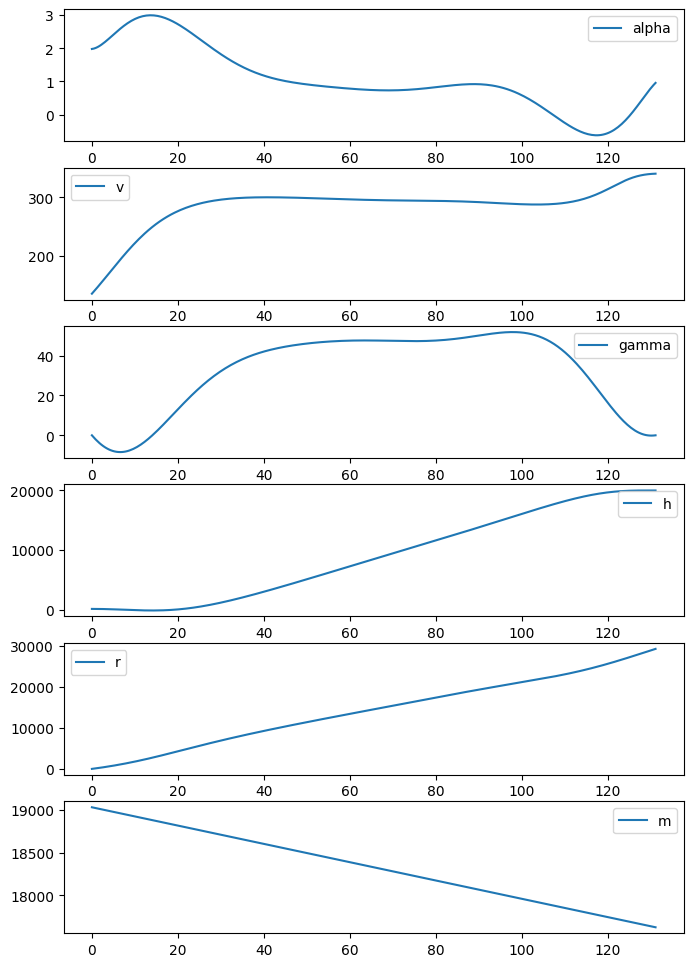

In [20]:
import numpy as np
from scipy.optimize import minimize
from scipy.optimize import LinearConstraint, NonlinearConstraint
import matplotlib.pylab as plt

class VehicleDynamics:
    """
    This class contains the vehicle dynamics.

    You can get different results by providing a better implementation
    for the standard atmosphere or by writing better performance models
    for the lift, drag and thrust.
    """
    def __init__(self, S, CL_alpha, CD0, kappa, Isp, TtoW, Mcrit=0.8):
        """
        Initialize the vehicle dynamics

        Args:
            S: Reference area
            CL_alpha: Lift curve slope
            CD0: Zero lift drag coefficient
            kappa: Coefficient for quadratic term in the drag polar
            Isp: Specific thrust
            TtoW: Thrust-to-weight ratio
            Mcrit: Critical Mach number
        """

        self.S = S
        self.CL_alpha = CL_alpha
        self.CD0 = CD0
        self.kappa = kappa
        self.Isp = Isp
        self.TtoW = TtoW
        self.Mcrit = Mcrit
        self.m0 = 19030.0

        self.gamma = 1.4 # Ratio of specific heats
        self.R = 287.058 # Gas constant for air
        self.g = 9.81 # m/s^2

        return

    def getInitConditions(self):
        """Get the initial conditions"""

        v0 = 136.0 # m/s
        gamma0 = 0.0 # radians
        h0 = 100.0 # m
        r0 = 0.0 # m

        return [v0, gamma0, h0, r0, self.m0]

    def getTargetConditions(self):
        """Get the conditions at the final time"""

        hf = 20000.0 # 20 km
        vf = self.getAtmSoundSpeed(hf)
        gammaf = 0.0

        return [vf, gammaf, hf, None, None]

    def getTargetScale(self):
        """Get the scaling factors for the conditions at the final time"""
        return [100.0, 1.0, 1000.0, None, None]

    def getNumStates(self):
        """Get the number of state variables"""
        return 5

    def getNumControlStates(self):
        """
        Get the number of control states
        """
        return 1

    def getAtmTemperature(self, h):
        """Given the altitude h, compute the temperature"""
        return 288.15 # K

    def getAtmDensity(self, h):
        """Given the altitude h, compute the density"""
        return 1.225 # kg/m^3

    def getAtmSoundSpeed(self, h):
        """Given the altitude h, compute the speed of sound"""
        T = self.getAtmTemperature(h)
        return np.sqrt(self.gamma * self.R * T)

    def getCL(self, alpha, Mach):
        """
        Given the angle of attack and Mach number, compute the lift coefficient
        """
        # Convert from degrees to radians
        conv = np.pi / 180.0
        return self.CL_alpha * conv * alpha

    def getCD(self, CL, Mach):
        """
        Given the coefficient of lift and the Mach number, compute the drag
        """
        if Mach >= self.Mcrit:
            return self.CD0 + self.kappa * CL**2 + 20.0 * (Mach - self.Mcrit)**4
        else:
            return self.CD0 + self.kappa * CL**2

    def getThrust(self, h, v):
        """Compute the thrust given the altitude and speed"""
        T = self.TtoW * self.m0 * self.g
        return T

    def getIsp(self, h):
        """Get the specific impulse"""
        return self.Isp

    def computeSystemResidual(self, qdot, q, x, res):
        """
        Compute the system residual.

        The state vector consists of the variables

        q = [v, gamma, h, r, m]

        v: The velocity [m/s]
        gamma: The flight path angle [degrees]
        h: The altitude [m]
        r: The distance flown [m]
        m: The mass of the aircraft [m]

        Args:
            qdot: The time derivatives of the states
            q: The state values
            x: The scalar control input
            res: The residual values
        """
        v = q[0]
        gamma = q[1]
        h = q[2]
        r = q[3]
        m = q[4]

        Mach = v/self.getAtmSoundSpeed(h)
        rho = self.getAtmDensity(h)
        CL = self.getCL(x, Mach)
        CD = self.getCD(CL, Mach)
        Isp = self.getIsp(h)
        T = self.getThrust(h, v)

        qinfty = 0.5 * rho * v**2
        D = qinfty * self.S * CD
        L = qinfty * self.S * CL
        g = self.g

        # Convert from degrees to radians
        conv = np.pi / 180.0
        res[0] = qdot[0] - ((T/m) * np.cos(conv * x) - (D/m) - g * np.sin(conv * gamma))
        res[1] = qdot[1] - (T/(m * v) * np.sin(conv * x) + L/(m * v) - (g/v) * np.cos(conv * gamma))/conv
        res[2] = qdot[2] - v * np.sin(conv * gamma)
        res[3] = qdot[3] - v * np.cos(conv * gamma)
        res[4] = qdot[4] + T/(g * Isp)

        return

    def computeSystemJacobian(self, alpha, beta, qdot, q, x, J):
        """
        Compute the system Jacobian matrix

        J = alpha * dR/dq + beta * dR/dqdot

        Args:
            alpha: coefficient for the Jacobian w.r.t. states
            beta: coefficient for the Jacobian w.r.t. time derivatives of states
            qdot: The time derivatives of the states
            q: The state values
            x: The scalar control input
            J: The Jacobian matrix
        """

        if np.iscomplexobj(q):
            # Allocate a perturbation vector
            e0 = np.zeros(5, dtype=float)
            res0 = np.zeros(5, dtype=complex)

            dh = 1e-30
            for i in range(5):
                e0[:] = 0.0
                e0[i] = 1.0
                q0 = q.real + 1j * dh * alpha * e0
                q0dot = qdot.real + 1j * dh * beta * e0
                self.computeSystemResidual(q0dot, q0, x.real, res0)
                J[:, i] = res0.imag/h
        else:
            # Allocate a perturbation vector
            e0 = np.zeros(5, dtype=float)
            res = np.zeros(5, dtype=complex)

            dh = 1e-30
            for i in range(5):
                e0[:] = 0.0
                e0[i] = 1.0
                q0 = q + 1j * dh * alpha * e0
                q0dot = qdot + 1j * dh * beta * e0
                self.computeSystemResidual(q0dot, q0, x, res)
                J[:, i] = res.imag/dh

        return

    def computeSystemControlJacobian(self, qdot, q, x, Jx):
        """
        Compute the Jacobian matrix with respect to the scalar control

        Jx = dR/dx

        Args:
            qdot: The time derivatives of the states
            q: The state values
            x: The scalar control input
            Jx: The Jacobian vector with respect to the control
        """

        if np.iscomplexobj(q):
            # Compute the system residuals at the initial state
            res0 = np.zeros(5, dtype=complex)

            # Perturb in the control variable
            dh = 1e-30
            self.computeSystemResidual(qdot.real, q.real, x.real + 1j * dh, res0)
            Jx[:] = res0.imag/dh
        else:
            # Compute the system residuals at the initial state
            res0 = np.zeros(5, dtype=complex)

            # Perturb in the control variable
            dh = 1e-30
            self.computeSystemResidual(qdot, q, x + 1j * dh, res0)
            Jx[:] = res0.imag/dh

        return

class MinTimeTrajectory:
    """
    This class takes the system dynamics as an argument and can
    perform simulation of the minimum time-to-climb problem.
    """
    def __init__(self, system, num_time_steps, num_ctrl_pts):
        """
        Initialize the MinTimeTrajectory class

        Args:
            system: The system dynamics
            num_time_steps: The number of time steps to use
            num_ctrl_pts: The number of points for the control
        """
        self.system = system
        self.num_states = self.system.getNumStates()
        self.num_time_steps = num_time_steps
        self.num_ctrl_pts = num_ctrl_pts
        self.num_design_vars = self.num_ctrl_pts + 1
        self.fig = None
        self.ax = None

        # Set up the knots for the basis functions
        self.knots = 0.5 - 0.5 * np.cos(np.linspace(0, np.pi, self.num_ctrl_pts))

        # Set the initial conditions
        self.qinit = np.array(self.system.getInitConditions())

        # Count up the number of final constraints
        self.qtarget = self.system.getTargetConditions()
        count = 0
        for qval in self.qtarget:
            if qval is not None:
                count += 1
        self.num_constraints = count

        # Solution parameters
        self.max_newton_iters = 10
        self.newton_tol = 1e-10

        return

    def evalInterp(self, u):
        """Given a parametric point, u, evaluate the Lagrange basis"""
        N = np.ones(self.num_ctrl_pts)
        for i in range(self.num_ctrl_pts):
            for j in range(self.num_ctrl_pts):
                if i != j:
                    N[i] *= (u - self.knots[j])/(self.knots[i] - self.knots[j])

        return N

    def getControl(self, u, x):
        """Return the control value given the parametric point u and x input"""

        return np.dot(self.evalInterp(u), x[:-1])

    def addControlDeriv(self, u, dfdctrl, dfdx):
        """Add the derivative of a function w.r.t. the control to the derivative w.r.t. x"""

        N = self.evalInterp(u)
        dfdx[:-1] += dfdctrl * N
        return

    def evalObj(self, x):
        """
        Evaluate the objective

        In this case, the design vector consists of the control point values and
        the final entry contains the simulation time.

        x = [alpha_0, alpha_1, ..., alpha_{num_ctrl_pts-1}, tf]
        """

        # Compute the sum square of the weights
        fobj = x[-1]

        return fobj

    def evalObjGradient(self, x):
        """Evaluate the objective gradient"""

        g = np.zeros(x.shape, dtype=x.dtype)
        g[-1] = 1.0

        return g

    def evalCon(self, x):
        """Evaluate the constraints"""

        # Compute the full trajectory based on the input
        self.q = self.computeTrajectory(x)

        # Compute the constraints
        con = np.zeros(self.num_constraints, dtype=x.dtype)

        count = 0
        scale = self.system.getTargetScale()
        for state, qval in enumerate(self.qtarget):
            if qval is not None:
                con[count] = (self.q[-1, state] - qval)/scale[state]
                count += 1

        print('Objective = ', x[-1], 'Constraints = ', con)
        return con

    def evalConGradient(self, x, interactive=True):
        """Evaluate the constraint gradient"""

        # Compute the full trajectory
        q = self.computeTrajectory(x)

        # Create a vector to store the derivative of the constraints
        dcdx = np.zeros((self.num_constraints, self.num_design_vars), dtype=x.dtype)

        count = 0
        scale = self.system.getTargetScale()
        for state, qval in enumerate(self.qtarget):
            if qval is not None:
                self.computeAdjointDeriv(q, x, state, dcdx[count, :])
                dcdx[count, :] /= scale[state]
                count += 1

        self.visualize(x, q, interactive=interactive)

        return dcdx

    def computeTrajectory(self, x):
        """
        Given the design variable vector, compute the state history.

        x = [alpha_0, alpha_1, ..., alpha_{num_ctrl_pts-1}, tf]

        Args:
            x: The design variable vector

        Returns:
            q: The state variables
        """

        # Set the time steps
        self.t = np.linspace(0, x[-1], self.num_time_steps + 1)

        # Allocate space for the state variables
        q = np.zeros((self.num_time_steps + 1, self.num_states), dtype=x.dtype)

        # Set the initial conditions.
        q[0, :] = self.qinit

        # Compute the residual and Jacobian
        res = np.zeros(self.num_states, dtype=q.dtype)
        J = np.zeros((self.num_states, self.num_states), dtype=q.dtype)

        # Integrate forward in time
        for k in range(1, self.num_time_steps + 1):
            # Copy the starting point for the first iteration
            q[k, :] = q[k-1, :]

            # Solve the nonlinear equations for q[k]
            for j in range(self.max_newton_iters):
                # Compute the state values at the mid-point
                alpha = 0.5
                qk = alpha*(q[k, :] + q[k-1, :])

                # Compute the time derivative approximation
                beta = 1.0/(self.t[k] - self.t[k-1])
                qkdot = beta*(q[k, :] - q[k-1, :])

                # Compute the control value at the mid-point
                xk = self.getControl((k - 0.5)/self.num_time_steps, x)

                # Compute the residuals
                self.system.computeSystemResidual(qkdot, qk, xk, res)

                # Compute the system Jacobian matrix
                self.system.computeSystemJacobian(alpha, beta, qkdot, qk, xk, J)

                # Solve for the update using Newton's method
                try:
                    update = np.linalg.solve(J, res)
                except:
                    print('Jacobian factorization failed')
                    print(J)
                    exit(0)
                q[k, :] -= update

                # Check for convergence
                rnorm = np.sqrt(np.dot(res, res))
                if rnorm < self.newton_tol:
                    break
            else:
                rnorm = np.sqrt(np.dot(res, res))
                print('Newton method failed with norm [%3d] = %25.10e'%(k, rnorm))

        return q

    def computeAdjointDeriv(self, q, x, state, dfdx):
        """
        Compute the derivative of the final state with the specified state
        index with respect to the control.
        """

        # Set the time steps
        self.t = np.linspace(0, x[-1], self.num_time_steps + 1)

        # Zero-out the contributions to the state variables
        dfdx[:] = 0.0

        # Set the right-hand-side for the adjoint equations
        res = np.zeros(self.num_states, dtype=dfdx.dtype)
        res[state] = 1.0 # df/du

        # The Jacobian matrix
        J = np.zeros((self.num_states, self.num_states), dtype=dfdx.dtype)

        # The Jacobian matrix w.r.t. the control
        Jx = np.zeros(self.num_states, dtype=dfdx.dtype)

        # Integrate the adjoint in reverse
        for k in range(self.num_time_steps, 0, -1):
            # Compute the state values at the mid-point
            alpha = 0.5
            qk = alpha*(q[k, :] + q[k-1, :])

            # Compute the time derivative approximation
            beta = 1.0/(self.t[k] - self.t[k-1])
            qkdot = beta*(q[k, :] - q[k-1, :])

            # Compute the control value
            xk = self.getControl((k - 0.5)/self.num_time_steps, x)

            # Compute the Jacobian matrix
            self.system.computeSystemJacobian(alpha, beta, qkdot, qk, xk, J)

            # Compute the adjoint variables
            adjoint = -np.linalg.solve(J.T, res)

            # Compute the control input Jacobian
            self.system.computeSystemControlJacobian(qkdot, qk, xk, Jx)

            # Add the contribution from the total derivative
            dfdctrl = np.dot(Jx, adjoint)

            # Add the control derivative
            self.addControlDeriv((k - 0.5)/self.num_time_steps, dfdctrl, dfdx)

            # Add the contributions from the time derivative
            dfdx[-1] -= beta * (1.0 / self.num_time_steps) * np.dot(qkdot, adjoint)

            # Compute the right-hand-side for the next adjoint
            self.system.computeSystemJacobian(alpha, -beta, qkdot, qk, xk, J)

            # Update the right-hand-side for the adjoint
            res = np.dot(J.T, adjoint)

        return

    def getControlTrajectory(self, x):
        """Compute the control trajectory for visualization"""
        u = np.zeros(self.num_time_steps + 1)

        for k in range(self.num_time_steps + 1):
            u[k] = self.getControl(k/self.num_time_steps, x)

        return u

    def visualize(self, x, q, interactive=True):
        """
        Visualize the result.

        During an optimization, use interactive=True so that the
        plot will update as the optimization problem is solved.
        """

        if self.fig is None:
            self.fig, self.ax = plt.subplots(6, 1, figsize=(8, 12))
            if interactive:
                plt.ion()
                plt.show()

        for a in self.ax:
            a.clear()

        # Set the time steps
        t = np.linspace(0, x[-1], self.num_time_steps + 1)

        u = self.getControlTrajectory(x)
        self.ax[0].plot(t, u, label='alpha')
        self.ax[1].plot(t, q[:, 0], label='v')
        self.ax[2].plot(t, q[:, 1], label='gamma')
        self.ax[3].plot(t, q[:, 2], label='h')
        self.ax[4].plot(t, q[:, 3], label='r')
        self.ax[5].plot(t, q[:, 4], label='m')

        for a in self.ax:
            a.legend()

        if interactive:
            plt.pause(0.01)

        self.fig.canvas.draw()

        return

# Set the vehicle dynamics parameters
S = 49.2386 # m^2
Isp = 1600.0 # s
CD0 = 0.013
CL_alpha = 3.44
kappa = 0.54
TtoW = 0.9 # Thrust-to-weight ratio

# Initial guess for the time
tf_guess = 300.0 # s

# Initialie the vehicle dynamics
dynamics = VehicleDynamics(S, CL_alpha, CD0, kappa, Isp, TtoW, Mcrit=0.8)

# Set the number of points to use for the control
num_ctrl_pts = 10
num_time_steps = 300

# Set up the minimum time-to-climb
problem = MinTimeTrajectory(dynamics, num_time_steps, num_ctrl_pts)

# Number of design variables
num_design_vars = problem.num_design_vars

# Set the initial guess
x = np.zeros(num_design_vars)
x[:-1] = -0.25 + 2.0 * problem.knots
x[5:-1] = 0.0
x[-1] = tf_guess

# Set bounds for the design problem. You can adjust these
bounds = []
for i in range(num_design_vars-1):
    bounds.append((-5.0, 5.0)) # Set -5 degrees, 5 degrees as the bound for AOA

# Set the bounds for the tf value
bounds.append((100.0, None))

# Perform a complex-step verification for the adjoint
h = 1e-30
p = np.random.uniform(size=num_design_vars)

dcdx = problem.evalConGradient(x, interactive=False)
adjoint_result = np.dot(dcdx, p)
cs_result = problem.evalCon(x + h * 1j * p).imag/h

print('Adjoint check')
print('{0:>25s} {1:>25s} {2:>25s}'.format('Adjoint', 'Complex step', 'Relative error'))
for adjoint, cs in zip(adjoint_result, cs_result):
    print('{0:25.15e} {1:25.15e} {2:25.15e}'.format(adjoint, cs, (adjoint - cs)/cs))

# Solve the problem using the reduced-space method with the adjoint implementation
# Set up the nonlinear constraint for the final state variables.
lb = np.zeros(problem.num_constraints)
ub = np.zeros(problem.num_constraints)
con = NonlinearConstraint(problem.evalCon, lb, ub,
                          jac=problem.evalConGradient)

# Solve the minimum time to climb problem
# res = minimize(problem.evalObj, x, bounds=bounds, method='trust-constr',
#                jac=problem.evalObjGradient,
#                # hess = lambda x: np.zeros((num_design_vars, num_design_vars)),
#                constraints=con, options={'maxiter': 500})

# print(res)

# This is the optimized result from the code above
x = np.array([1.98051099,   
              2.29132371,   
              2.97654095,   
              1.59640878,
              0.84958588,
              0.78274204,
              0.68233916,
              -0.6039627,
              0.30521184,
              0.95565241,
              131.06729561])

q = problem.computeTrajectory(x)
problem.visualize(x, q, interactive=False)

### The Brachistochrone

Given an initial point and a final point, find the path between these points such that the time taken by a particle moving along the path is minimized.

https://openmdao.github.io/dymos/examples/brachistochrone/brachistochrone.html

For the class project, you may want to use Dymos to help solve your optimization problems. Dymos is built on OpenMDAO and is designed to couple multiple complex components together into a simulation. Dymos adds the capability to perform trajectory optimization.

Here's a video with an intro to Dymos:

https://www.youtube.com/watch?v=e52KczetQX0

In this problem, the system dynamics are

\begin{align*}
\dot{x} &= v \sin(\theta) \\
\dot{y} &= - v \cos(\theta) \\
\dot{v} &= g \cos(\theta) \\
\end{align*}

The initial conditions are 

\begin{align*}
x(0) &= 0 \\
y(0) &= 10 \\
v(0) &= 0 \\
\end{align*}

The final conditions are

\begin{align*}
x(t_{f}) &= 0 \\
y(t_{f}) &= 5 \\
\end{align*}

There are three key steps to solving this problem

1. Setting up the dynamics of the problem using OpenMDAO components. Here we'll focus on a simple `ExplicitComponent` implementation. This will also work with a `Group` that contains a number of components.
2. Testing the dynamics that you've implemented. If the derivative checks do not pass, your simulation and optimization will not work.
3. Setting up/running the optimization problem.

The following code defines the dynamics of the Brachistochrone problem.

In [21]:
import numpy as np
import openmdao.api as om

class BrachistochroneODE(om.ExplicitComponent):

    def initialize(self):
        self.options.declare('num_nodes', types=int)
        self.options.declare('static_gravity', types=(bool,), default=False,
                             desc='If True, treat gravity as a static (scalar) input, rather than '
                                  'having different values at each node.')

    def setup(self):
        nn = self.options['num_nodes']

        # Inputs
        self.add_input('v', val=np.zeros(nn), desc='velocity', units='m/s')

        if self.options['static_gravity']:
            self.add_input('g', val=9.80665, desc='grav. acceleration', units='m/s/s',
                           tags=['dymos.static_target'])
        else:
            self.add_input('g', val=9.80665 * np.ones(nn), desc='grav. acceleration', units='m/s/s')

        self.add_input('theta', val=np.ones(nn), desc='angle of wire', units='rad')

        self.add_output('xdot', val=np.zeros(nn), desc='velocity component in x', units='m/s',
                        tags=['dymos.state_rate_source:x', 'dymos.state_units:m'])

        self.add_output('ydot', val=np.zeros(nn), desc='velocity component in y', units='m/s',
                        tags=['dymos.state_rate_source:y', 'dymos.state_units:m'])

        self.add_output('vdot', val=np.zeros(nn), desc='acceleration magnitude', units='m/s**2',
                        tags=['dymos.state_rate_source:v', 'dymos.state_units:m/s'])

        self.add_output('check', val=np.zeros(nn), desc='check solution: v/sin(theta) = constant',
                        units='m/s')

        # Setup partials
        arange = np.arange(self.options['num_nodes'])
        self.declare_partials(of='vdot', wrt='theta', rows=arange, cols=arange)

        self.declare_partials(of='xdot', wrt='v', rows=arange, cols=arange)
        self.declare_partials(of='xdot', wrt='theta', rows=arange, cols=arange)

        self.declare_partials(of='ydot', wrt='v', rows=arange, cols=arange)
        self.declare_partials(of='ydot', wrt='theta', rows=arange, cols=arange)

        self.declare_partials(of='check', wrt='v', rows=arange, cols=arange)
        self.declare_partials(of='check', wrt='theta', rows=arange, cols=arange)

        if self.options['static_gravity']:
            c = np.zeros(self.options['num_nodes'])
            self.declare_partials(of='vdot', wrt='g', rows=arange, cols=c)
        else:
            self.declare_partials(of='vdot', wrt='g', rows=arange, cols=arange)

    def compute(self, inputs, outputs):
        theta = inputs['theta']
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)
        g = inputs['g']
        v = inputs['v']

        outputs['vdot'] = g * cos_theta
        outputs['xdot'] = v * sin_theta
        outputs['ydot'] = -v * cos_theta
        outputs['check'] = v / sin_theta

    def compute_partials(self, inputs, partials):
        theta = inputs['theta']
        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)
        g = inputs['g']
        v = inputs['v']

        partials['vdot', 'g'] = cos_theta
        partials['vdot', 'theta'] = -g * sin_theta

        partials['xdot', 'v'] = sin_theta
        partials['xdot', 'theta'] = v * cos_theta

        partials['ydot', 'v'] = -cos_theta
        partials['ydot', 'theta'] = v * sin_theta

        partials['check', 'v'] = 1 / sin_theta
        partials['check', 'theta'] = -v * cos_theta / sin_theta ** 2

#### Testing the derivatives

In OpenMDAO and in Dymos the complex-step method can be used to test the derivatives implemented in the component classes.

The following code instantiates the `BrachistochroneODE` class and tests its derivatives.

In [22]:
import numpy as np
import openmdao.api as om

num_nodes = 5

# Create an OpenMDAO problem
p = om.Problem(model=om.Group())

# Set up the independent variables that will be treated as inputs to the model. 
# These variables are outputs from a source component - the IndepVarComp.
ivc = p.model.add_subsystem('vars', om.IndepVarComp())
ivc.add_output('v', shape=(num_nodes,), units='m/s')
ivc.add_output('theta', shape=(num_nodes,), units='deg')

# Add the component to the model
p.model.add_subsystem('ode', BrachistochroneODE(num_nodes=num_nodes))

# Connect the input to the output
p.model.connect('vars.v', 'ode.v')
p.model.connect('vars.theta', 'ode.theta')

# Force everything to be allocated in complex
p.setup(force_alloc_complex=True)

# Set random input variable values into the IVC
p.set_val('vars.v', 10*np.random.random(num_nodes))
p.set_val('vars.theta', 10*np.random.uniform(1, 179, num_nodes))

# Run the model to propagate values
p.run_model()

# Check if the partial pass
cpd = p.check_partials(method='cs', compact_print=True)

-----------------------------------
Component: BrachistochroneODE 'ode'
-----------------------------------

'<output>' wrt '<variable>' | calc mag.  | check mag. | a(cal-chk) | r(cal-chk)
-------------------------------------------------------------------------------

'check'    wrt 'g'          | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | nan
'check'    wrt 'theta'      | 1.3798e+04 | 1.3798e+04 | 8.8818e-16 | 6.4369e-20
'check'    wrt 'v'          | 2.5257e+02 | 2.5257e+02 | 4.4409e-16 | 1.7583e-18
'vdot'     wrt 'g'          | 1.8669e+00 | 1.8669e+00 | 1.1102e-16 | 5.9470e-17
'vdot'     wrt 'theta'      | 1.2070e+01 | 1.2070e+01 | 1.3323e-15 | 1.1038e-16
'vdot'     wrt 'v'          | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | nan
'xdot'     wrt 'g'          | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | nan
'xdot'     wrt 'theta'      | 5.4239e+00 | 5.4239e+00 | 0.0000e+00 | 0.0000e+00
'xdot'     wrt 'v'          | 1.2308e+00 | 1.2308e+00 | 1.2413e-16 | 1.0085e-16
'ydot'     wrt 'g'          | 0

#### Solving the problem

Now we want to solve the optimization problem.

A trajectory is composed of one or more phases. These phases can be linked together, but for the Brachistochrone problem, we only need one phase.

Here `x`, `y` and `v` are treated as states since they are governed by the ODE. The angle `theta` is a control variable. The input `g` is treated as a constant parameter that does not change.



--- Constraint Report [traj] ---
    --- phase0 ---
        None



/usr/local/lib/python3.9/site-packages/openmdao/recorders/sqlite_recorder.py:227: UserWarning:The existing case recorder file, dymos_solution.db, is being overwritten.


Model viewer data has already been recorded for Driver.
Full total jacobian was computed 3 times, taking 0.135166 seconds.
Total jacobian shape: (40, 50) 


Jacobian shape: (40, 50)  (19.85% nonzero)
FWD solves: 13   REV solves: 0
Total colors vs. total size: 13 vs 50  (74.0% improvement)

Sparsity computed using tolerance: 1e-25
Time to compute sparsity: 0.135166 sec.
Time to compute coloring: 0.078482 sec.
Memory to compute coloring: 0.019531 MB.
Optimization terminated successfully    (Exit mode 0)
            Current function value: [18.0161673]
            Iterations: 24
            Function evaluations: 24
            Gradient evaluations: 24
Optimization Complete
-----------------------------------
[1.80161673]

Simulating trajectory traj
Done simulating trajectory traj


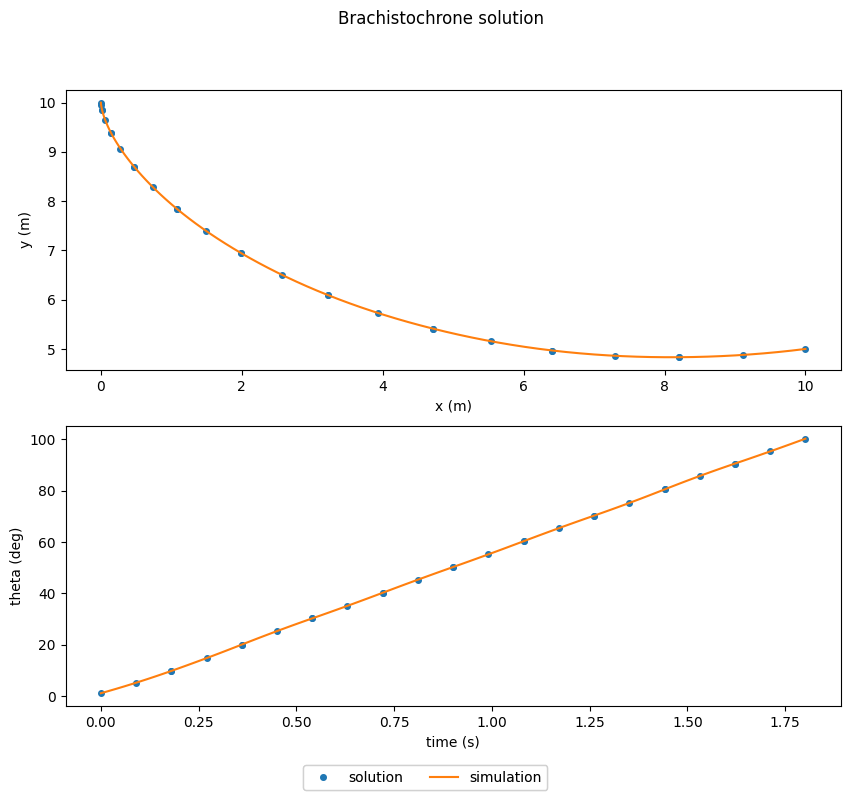

In [23]:
import openmdao.api as om
import dymos as dm
from dymos.examples.plotting import plot_results
import matplotlib.pyplot as plt

# Initialize the Problem and the optimization driver
p = om.Problem(model=om.Group())
p.driver = om.ScipyOptimizeDriver()
p.driver.declare_coloring()

# Create a trajectory and add a phase to it
traj = p.model.add_subsystem('traj', dm.Trajectory())

phase = traj.add_phase('phase0',
                       dm.Phase(ode_class=BrachistochroneODE,
                                transcription=dm.GaussLobatto(num_segments=10)))

# Set the variables
phase.set_time_options(fix_initial=True, duration_bounds=(.5, 10))

# Add state variables and specify whether to apply initial or final conditions
phase.add_state('x', fix_initial=True, fix_final=True)
phase.add_state('y', fix_initial=True, fix_final=True)
phase.add_state('v', fix_initial=True, fix_final=False)

# Add the control parameter
phase.add_control('theta', continuity=True, rate_continuity=True,
                  units='deg', lower=0.01, upper=179.9)

# Add gravity as a parameter
phase.add_parameter('g', units='m/s**2', val=9.80665)

# Set the objective -- Minimize time at the end of the phase
phase.add_objective('time', loc='final', scaler=10)

# Set the type of linear solver to use
p.model.linear_solver = om.DirectSolver()

# Setup the Problem
p.setup()

# Set the initial values
p['traj.phase0.t_initial'] = 0.0
p['traj.phase0.t_duration'] = 2.0

# Set the initial values
p.set_val('traj.phase0.states:x', phase.interp('x', ys=[0, 10]))
p.set_val('traj.phase0.states:y', phase.interp('y', ys=[10, 5]))
p.set_val('traj.phase0.states:v', phase.interp('v', ys=[0, 9.9]))
p.set_val('traj.phase0.controls:theta', phase.interp('theta', ys=[5, 100.5]))

# Solve for the optimal trajectory
dm.run_problem(p)

# Check the results
print(p.get_val('traj.phase0.timeseries.time')[-1])

# Generate the explicitly simulated trajectory
exp_out = traj.simulate()

plot_results([('traj.phase0.timeseries.states:x', 'traj.phase0.timeseries.states:y',
               'x (m)', 'y (m)'),
              ('traj.phase0.timeseries.time', 'traj.phase0.timeseries.controls:theta',
               'time (s)', 'theta (deg)')],
               title="Brachistochrone solution",
             p_sol=p, p_sim=exp_out)

plt.show()